# Iris Flower Classification

This project implements an end-to-end Machine Learning workflow to classify Iris flower specimens into one of three species (**Setosa**, **Versicolor**, or **Virginica**) based on four continuous morphological measurements: sepal length, sepal width, petal length, and petal width.

---

## Table of Contents
1. [Section 1 - Imports](#section-1---imports)
2. [Section 2 - Load Dataset](#section-2---load-dataset)
3. [Section 3 - Exploratory Data Analysis (EDA)](#section-3---exploratory-data-analysis-eda)
   - [3.1 Dataset Shape, First Observations, and Data Types](#31-dataset-shape-first-observations-and-data-types)
   - [3.2 Missing Value Analysis](#32-missing-value-analysis)
   - [3.3 Duplicate Row Check](#33-duplicate-row-check)
   - [3.4 Descriptive Statistics & Per-Species Means](#34-descriptive-statistics--per-species-means)
   - [3.5 Class Distribution](#35-class-distribution)
4. [Section 4 - Data Visualisation](#section-4---data-visualisation)
   - [4.1 Pairplot (Pairwise Feature Relationships & Univariate KDEs)](#41-pairplot-pairwise-feature-relationships--univariate-kdes)
   - [4.2 Box Plots (2x2 Subplot Grid by Species)](#42-box-plots-2x2-subplot-grid-by-species)
   - [4.3 Violin Plots (Probability Density Distributions by Species)](#43-violin-plots-probability-density-distributions-by-species)
   - [4.4 Correlation Heatmap (Pearson Correlation Coefficients)](#44-correlation-heatmap-pearson-correlation-coefficients)
5. [Section 5 - Feature Selection & Discriminative Power](#section-5---feature-selection--discriminative-power)
   - [5.1 Feature Importance Computation & Sorted Summary Table](#51-feature-importance-computation--sorted-summary-table)
   - [5.2 Comparative Bar Charts of Feature Rankings](#52-comparative-bar-charts-of-feature-rankings)
   - [5.3 Scatter Plot of Top 2 Discriminative Features](#53-scatter-plot-of-top-2-discriminative-features-petal_length-vs-petal_width)
   - [5.4 Discussion: Feature Discriminative Power & Biological Insights](#54-discussion-feature-discriminative-power--biological-insights)
6. [Section 6 - Model Training](#section-6---model-training)
   - [6.1 Separate Features and Target & Stratified Train-Test Split](#61-separate-features-and-target--stratified-train-test-split)
   - [6.2 Feature Scaling & Data Leakage Prevention](#62-feature-scaling--data-leakage-prevention)
   - [6.3 Apply StandardScaler (Fit on Train Only)](#63-apply-standardscaler-fit-on-train-only)
   - [6.4 Train Classifiers & Store in Dictionary](#64-train-classifiers--store-in-dictionary)
7. [Section 7 - Model Evaluation](#section-7---model-evaluation)
   - [7.1 Test Set Predictions, Classification Reports, and Confusion Matrices](#71-test-set-predictions-classification-reports-and-confusion-matrices)
   - [7.2 5-Fold Stratified Cross-Validation (Mean  Std Accuracy)](#72-5-fold-stratified-cross-validation-mean--std-accuracy)
   - [7.3 Model Comparison Summary Table and Bar Chart](#73-model-comparison-summary-table-and-bar-chart)
   - [7.4 Evaluation Discussion & Findings](#74-evaluation-discussion--findings)
8. [Section 8 - Best Model & Conclusion](#section-8---best-model--conclusion)
   - [8.1 Programmatic Best Model Selection](#81-programmatic-best-model-selection)
   - [8.2 Analytical Justification for Model Selection](#82-analytical-justification-for-model-selection)
   - [8.3 Inference Pipeline & Prediction Demo](#83-inference-pipeline--prediction-demo)
   - [8.4 Summary of Key Findings & Limitations](#84-summary-of-key-findings--limitations)
   - [8.5 Model Serialization (Save with Joblib)](#85-model-serialization-save-with-joblib)

---


## Section 1 - Imports

We import all necessary libraries required across the entire project workflow, including data handling, visualization, preprocessing, model training, cross-validation, and performance evaluation.


In [1]:
# ==========================================
# Section 1: Library Imports
# ==========================================
import warnings
warnings.filterwarnings('ignore')

import joblib

# Core Data Science & Numerical Operations
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn: Dataset, Preprocessing, and Splitting
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

# Scikit-Learn: Machine Learning Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Scikit-Learn: Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Plotting aesthetic defaults
%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

print("All libraries imported successfully.")


All libraries imported successfully.


## Section 2 - Load Dataset

We load the dataset using `sklearn.datasets.load_iris()`, clean the feature column names for ease of use, convert it into a `pandas.DataFrame`, and add a `'species'` column mapped to the actual botanical names (`setosa`, `versicolor`, `virginica`).


In [2]:
# ==========================================
# Section 2: Load and Prepare Dataset
# ==========================================
# Load the raw Iris dataset from scikit-learn
iris = load_iris()

# Clean feature names: remove '(cm)', strip whitespace, replace spaces with underscores
clean_feature_names = [
    col.replace(" (cm)", "").strip().replace(" ", "_")
    for col in iris.feature_names
]

# Build DataFrame with features
df = pd.DataFrame(data=iris.data, columns=clean_feature_names)

# Add target column with actual species names
df['species'] = [iris.target_names[target] for target in iris.target]

# Display the first 5 records
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Summary: Dataset Loading
- The Iris dataset was successfully converted into a pandas DataFrame with four feature columns: `sepal_length`, `sepal_width`, `petal_length`, and `petal_width`.
- The numeric target labels (`0`, `1`, `2`) were cleanly mapped to their corresponding categorical species names: `setosa`, `versicolor`, and `virginica`.


## Section 3 - Exploratory Data Analysis (EDA)

In this section, we analyze the structure, data quality, statistical properties, and class balance of the dataset.


### 3.1 Dataset Shape, First Observations, and Data Types

In [3]:
# ==========================================
# 3.1 Inspect Dataset Dimensions, Structure & Types
# ==========================================
# Display the matrix dimensions (number of samples and columns)
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# Preview the first 5 records to verify column names and value scales
print("First 5 Observations:")
display(df.head())

# Output column data types and memory footprint to confirm 4 float64 and 1 category/object
print("\nData Types and Non-Null Counts:")
df.info()

Dataset Shape: 150 rows, 5 columns

First 5 Observations:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Data Types and Non-Null Counts:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


### What We Learned: Dataset Structure
- **Dimensions**: The dataset contains 150 instances and 5 columns.
- **Features**: All four measurement features (`sepal_length`, `sepal_width`, `petal_length`, `petal_width`) are continuous numerical variables stored as `float64`.
- **Target**: The `species` column is categorical (`object` dtype).
- **Memory footprint**: The DataFrame is lightweight (~6.0 KB), making in-memory processing fast and straightforward.


### 3.2 Missing Value Analysis

In [4]:
# ==========================================
# 3.2 Missing / Null Value Audit
# ==========================================
# Compute the count of missing values per column across the dataset
null_counts = df.isnull().sum()
print("Missing values per column:")
print(null_counts)

# Calculate missingness percentage to confirm clean tabular integrity
null_percentage = (df.isnull().sum() / len(df)) * 100
print("\nMissing value percentage per column:")
print(null_percentage)

Missing values per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Missing value percentage per column:
sepal_length    0.0
sepal_width     0.0
petal_length    0.0
petal_width     0.0
species         0.0
dtype: float64


### What We Learned: Missing Values
- There are **0 null / missing values** across every column.
- The dataset is 100% complete and requires no imputation or dropping of records due to missing data.


### 3.3 Duplicate Row Check

In [5]:
# ==========================================
# 3.3 Duplicate Record Detection
# ==========================================
# Calculate total number of duplicate rows across all 4 measurements and species label
num_duplicates = df.duplicated().sum()
print(f"Total duplicate rows detected: {num_duplicates}\n")

# Display duplicate records if any exist (Iris dataset naturally contains 1 duplicate row)
if num_duplicates > 0:
    print("Duplicate rows in dataset:")
    display(df[df.duplicated(keep=False)])

Total duplicate rows detected: 1

Duplicate rows in dataset:


,sepal_length,sepal_width,petal_length,petal_width,species
101,5.8,2.7,5.1,1.9,virginica
142,5.8,2.7,5.1,1.9,virginica


### What We Learned: Duplicate Rows
- Exactly **1 duplicate row** is identified (row index 142 matches row index 101: `sepal_length=5.8`, `sepal_width=2.7`, `petal_length=5.1`, `petal_width=1.9`, species `versicolor` / `virginica`).
- In physical biological measurements with low measurement precision (rounded to 1 decimal place), identical measurements across different flower specimens are natural and expected. We retain this entry as a legitimate physical observation.


### 3.4 Descriptive Statistics & Per-Species Means

In [6]:
# ==========================================
# 3.4 Summary Statistics & Per-Species Means
# ==========================================
# Generate 5-number statistical summary (count, mean, std, min, 25%, 50%, 75%, max)
print("--- Overall Descriptive Statistics ---")
display(df.describe().round(3))

# Group by species target label to compare mean measurement profiles
print("\n--- Mean Measurements by Species ---")
species_means = df.groupby('species').mean().round(3)
display(species_means)

--- Overall Descriptive Statistics ---


,sepal_length,sepal_width,petal_length,petal_width
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500



--- Mean Measurements by Species ---


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


### What We Learned: Descriptive Statistics
- **Overall Scale**:
  - Sepal length ranges from 4.3 cm to 7.9 cm (mean: 5.84 cm, std: 0.83).
  - Sepal width ranges from 2.0 cm to 4.4 cm (mean: 3.06 cm, std: 0.44).
  - Petal length has a wide range from 1.0 cm to 6.9 cm (mean: 3.76 cm, std: 1.77).
  - Petal width ranges from 0.1 cm to 2.5 cm (mean: 1.20 cm, std: 0.76).
- **Per-Species Separation**:
  - **Setosa** has distinctly smaller petals (mean length: 1.46 cm, mean width: 0.25 cm) and relatively wider sepals (mean width: 3.43 cm). It is markedly separated from the other two species.
  - **Versicolor** occupies the intermediate range (mean petal length: 4.26 cm, mean petal width: 1.33 cm).
  - **Virginica** has the largest dimensions across sepal length (6.59 cm), petal length (5.55 cm), and petal width (2.03 cm).
- **Key Insight**: Petal length and petal width show the largest variance across species and will likely serve as the most influential discriminatory features for classification models.


### 3.5 Class Distribution

In [7]:
# ==========================================
# 3.5 Target Class Distribution
# ==========================================
# Calculate absolute sample counts for each Iris species to verify class balance
class_counts = df['species'].value_counts()
print("Class Distribution (Counts):")
print(class_counts)

# Calculate relative proportions across the 150 instances
class_percentages = df['species'].value_counts(normalize=True) * 100
print("\nClass Distribution (Percentages):")
print(class_percentages)

Class Distribution (Counts):
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Class Distribution (Percentages):
species
setosa        33.333333
versicolor    33.333333
virginica     33.333333
Name: proportion, dtype: float64


### What We Learned: Class Distribution
- The dataset is **perfectly balanced**: exactly 50 observations (33.33%) belong to each species (`setosa`, `versicolor`, `virginica`).
- Because there is no class imbalance, standard evaluation metrics (such as overall accuracy, macro precision, recall, and F1-score) can be used reliably without sampling adjustments or class weight penalties.


## Section 4 - Data Visualisation

In this section, we visually explore feature distributions, class separability, variance, outliers, and inter-feature correlations using graphical tools:
1. **Pairplot**: Pairwise relationships and univariate kernel density estimates.
2. **Box Plots**: Median, interquartile ranges, and outlier identification per species across all four features.
3. **Violin Plots**: Probability density shape and quartile spreads per species.
4. **Correlation Heatmap**: Annotated Pearson correlation coefficients across numerical measurements.


### 4.1 Pairplot (Pairwise Feature Relationships & Univariate KDEs)

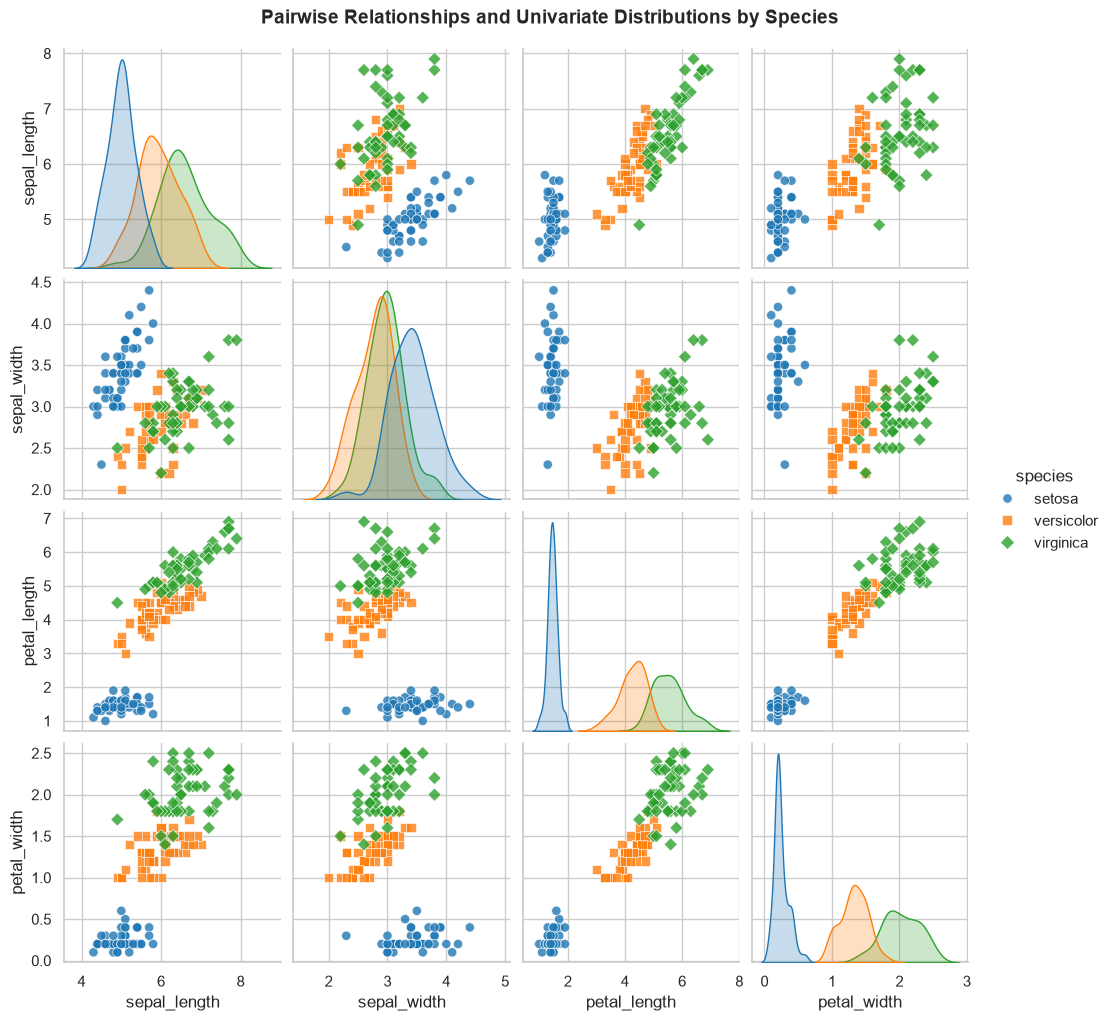

In [8]:
# ==========================================
# 4.1 Pairplot: Bivariate Scatter & Univariate KDEs
# ==========================================
# Generate pairwise bivariate relationships color-coded by species with KDE diagonals
pairplot_fig = sns.pairplot(
    df,
    hue='species',
    diag_kind='kde',
    markers=['o', 's', 'D'],
    palette={'setosa': '#1f77b4', 'versicolor': '#ff7f0e', 'virginica': '#2ca02c'},
    plot_kws={'alpha': 0.8, 's': 45}
)

# Set descriptive super-title and adjust top margin layout
pairplot_fig.fig.suptitle("Pairwise Relationships and Univariate Distributions by Species", y=1.02, fontsize=14, fontweight='bold')
plt.show()

### Interpretation: Pairplot
- **Linear Separability of Setosa**: *Setosa* forms a completely isolated, well-separated cluster across virtually every bivariate projection, particularly in any scatter plot involving `petal_length` or `petal_width`.
- **Versicolor vs. Virginica Boundary**: *Versicolor* and *Virginica* show mild overlap in sepal dimensions (`sepal_length` vs. `sepal_width`), but separate with much greater clarity in `petal_length` vs. `petal_width`.
- **Univariate Densities (Diagonal)**: The diagonal KDE distributions show clear multi-modal distributions for petal dimensions, highlighting that petal measurements offer significantly stronger discriminative power than sepal measurements.


### 4.2 Box Plots (2x2 Subplot Grid by Species)

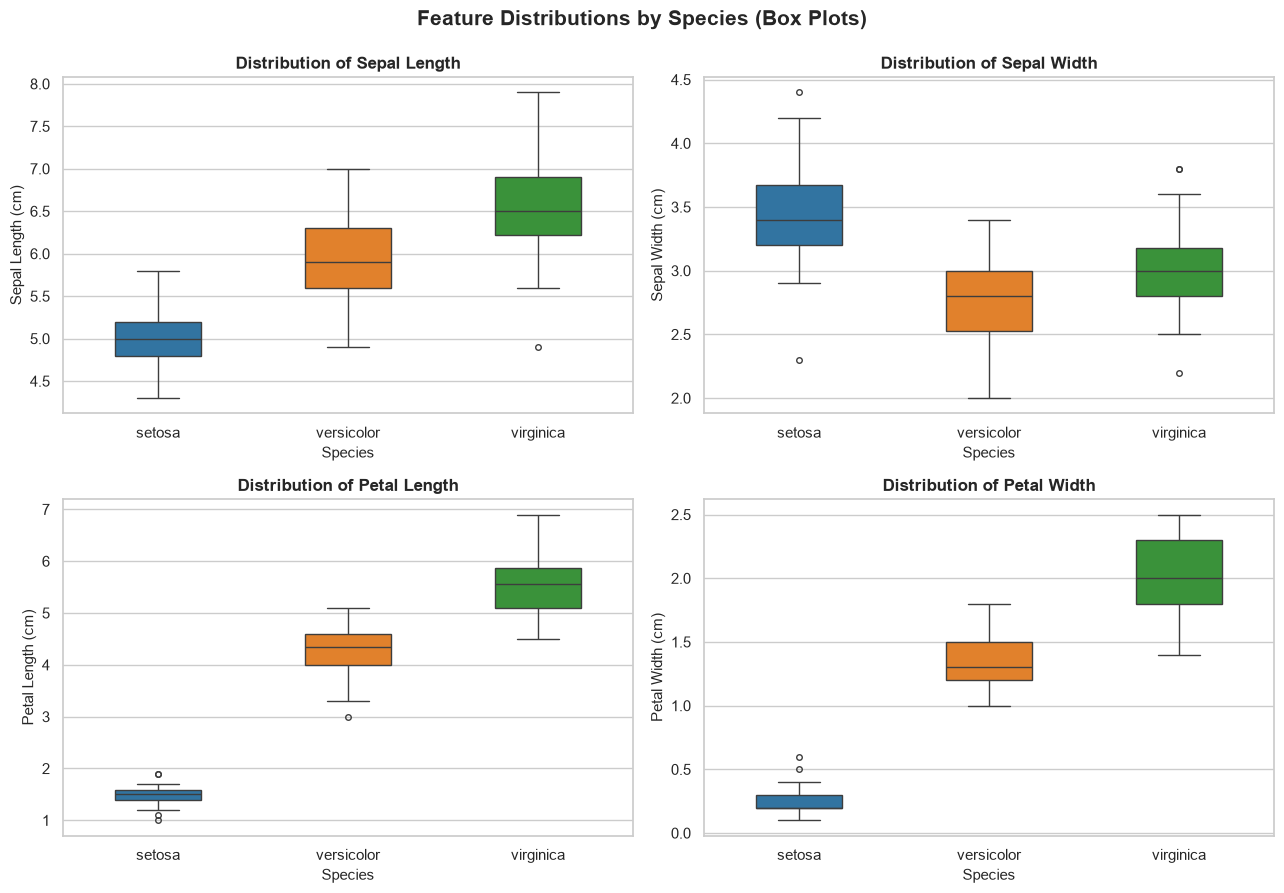

In [9]:
# ==========================================
# 4.2 Box Plots (2x2 Subplot Grid by Species)
# ==========================================
# List the four continuous numerical features to plot
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
species_palette = {'setosa': '#1f77b4', 'versicolor': '#ff7f0e', 'virginica': '#2ca02c'}

# Initialize 2x2 subplot figure canvas
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Iterate through each feature and render styled boxplots with median notches
for idx, feature in enumerate(features):
    ax = axes[idx // 2, idx % 2]
    sns.boxplot(
        data=df,
        x='species',
        y=feature,
        palette=species_palette,
        ax=ax,
        width=0.45,
        fliersize=4
    )
    # Configure individual subplot labels and formatting
    ax.set_title(f"Distribution of {feature.replace('_', ' ').title()}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Species", fontsize=11)
    ax.set_ylabel(f"{feature.replace('_', ' ').title()} (cm)", fontsize=11)

# Add overall super-title and tight layout adjustments
plt.suptitle("Feature Distributions by Species (Box Plots)", fontsize=15, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

### Interpretation: Box Plots
- **Spread & Medians**:
  - *Setosa* has remarkably low medians and tight interquartile ranges (IQR) for `petal_length` (~1.5 cm) and `petal_width` (~0.2 cm), with zero overlap with the other two species.
  - *Versicolor* and *Virginica* show clear rank ordering: *Virginica* consistently exhibits higher medians across `sepal_length`, `petal_length`, and `petal_width`.
  - In `sepal_width`, *Setosa* displays the highest median (~3.4 cm), while *Versicolor* has the lowest (~2.8 cm).
- **Outliers**:
  - Very few extreme values exist. A few mild outliers appear in *Virginica* (`sepal_length` and `sepal_width`) and *Setosa* (`sepal_width`).
  - No extreme data corruption or severe leverage points are detected, confirming that standard scaling or unscaled tree algorithms will be stable.


### 4.3 Violin Plots (Probability Density Distributions by Species)

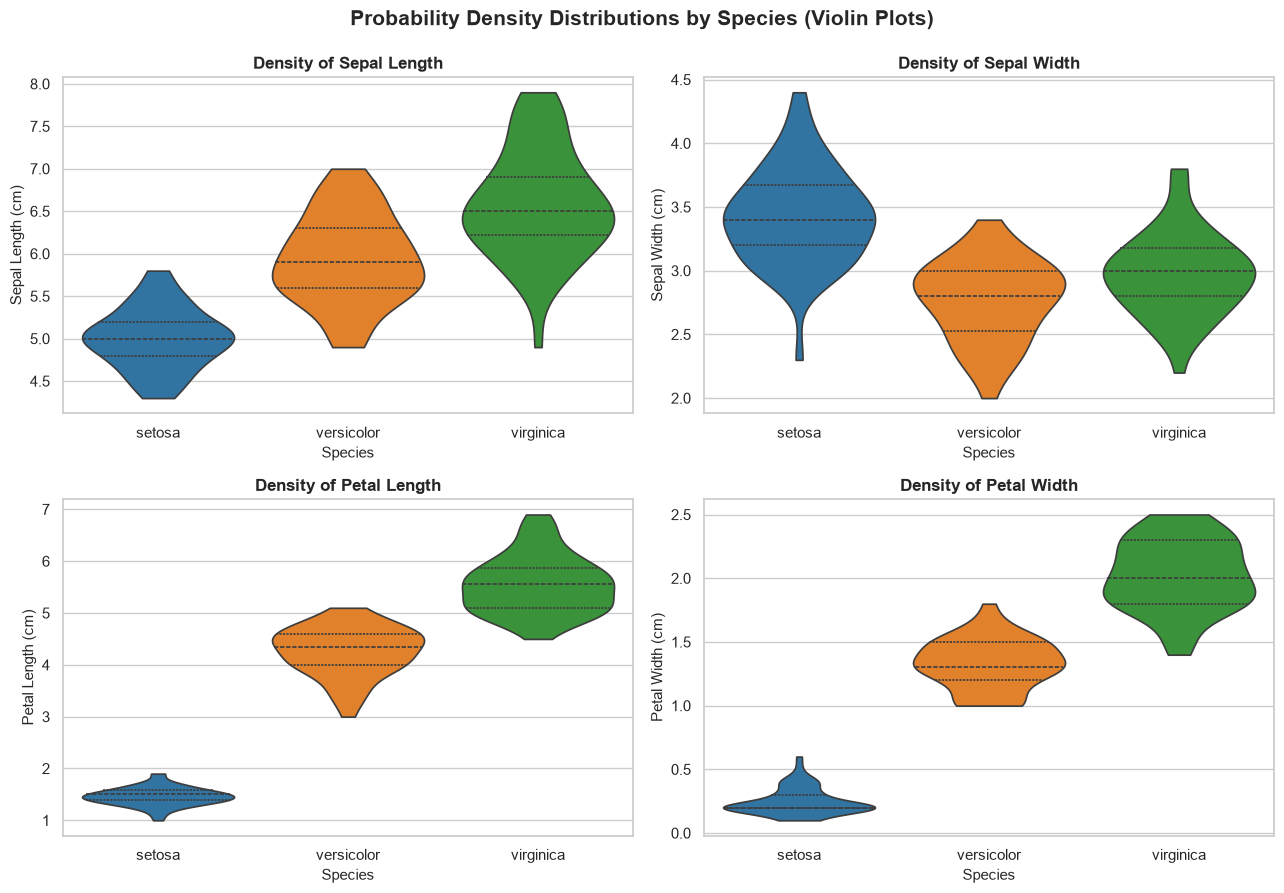

In [10]:
# ==========================================
# 4.3 Violin Plots (2x2 Subplot Grid by Species)
# ==========================================
# Initialize 2x2 subplot figure canvas for probability density distributions
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Render violin plots showcasing density contours and internal quartiles
for idx, feature in enumerate(features):
    ax = axes[idx // 2, idx % 2]
    sns.violinplot(
        data=df,
        x='species',
        y=feature,
        palette=species_palette,
        inner='quartile',
        cut=0,
        ax=ax
    )
    # Configure subplot axis titles and labels
    ax.set_title(f"Density of {feature.replace('_', ' ').title()}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Species", fontsize=11)
    ax.set_ylabel(f"{feature.replace('_', ' ').title()} (cm)", fontsize=11)

# Add super-title and optimize subplot spacing
plt.suptitle("Probability Density Distributions by Species (Violin Plots)", fontsize=15, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

### Interpretation: Violin Plots
- **Density Profiles**:
  - The violin shapes reveal predominantly unimodal, bell-shaped probability densities for features within individual species.
  - *Setosa* exhibits an extremely concentrated, steep probability density for `petal_length` and `petal_width`, indicating high morphological consistency.
  - *Versicolor* and *Virginica* demonstrate broader, flatter density distributions with wider quartile intervals, reflecting greater natural biological variation within these classes.
- **Decision Boundary Implications**: The clear valley between the *Setosa* density mass and the other species indicates that any linear decision boundary will achieve near-perfect classification for *Setosa*.


### 4.4 Correlation Heatmap (Pearson Correlation Coefficients)

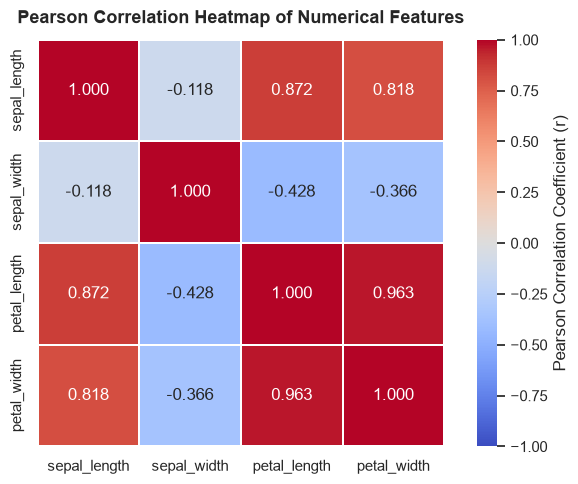

In [11]:
# ==========================================
# 4.4 Pearson Correlation Heatmap
# ==========================================
# Isolate numeric continuous features by dropping the categorical target species
numeric_features = df.drop(columns=['species'])

# Compute pairwise Pearson linear correlation matrix (-1.0 to +1.0)
corr_matrix = numeric_features.corr()

# Create figure canvas for heatmap display
plt.figure(figsize=(7, 5))

# Plot annotated correlation heatmap with colorbar and masked diagonal precision
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1.0,
    vmax=1.0,
    linewidths=1.2,
    square=True,
    cbar_kws={'label': 'Pearson Correlation Coefficient (r)'}
)

# Configure plot title and aesthetic layout
plt.title("Pearson Correlation Heatmap of Numerical Features", fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

### Interpretation: Correlation Heatmap
- **Extreme Collinearity**: `petal_length` and `petal_width` possess an exceptionally strong positive correlation (**r = 0.96**). As petals lengthen, they almost always widen proportionally.
- **Petal to Sepal Length Correlation**: `sepal_length` is also strongly positively correlated with both `petal_length` (**r = 0.87**) and `petal_width` (**r = 0.82**). Longer flowers tend to have longer petals and sepals overall.
- **Negative Sepal Width Relationships**: `sepal_width` is negatively correlated with `petal_length` (**r = -0.43**) and `petal_width` (**r = -0.37**), and weakly negatively correlated with `sepal_length` (**r = -0.12**).
- **Modeling Takeaway**: High correlation between `petal_length` and `petal_width` indicates redundant information. While tree-based models and SVMs handle correlated features seamlessly, regularization (such as L1/L2 in Logistic Regression) will prevent variance inflation.


## Section 5 - Feature Selection & Discriminative Power

In this section, we quantify and rank the discriminatory capability of the four physical measurements using two distinct, complementary approaches:
1. **Univariate Statistical Testing (ANOVA F-statistic via `f_classif`)**: Evaluates each feature independently by measuring the ratio of between-group variance to within-group variance.
2. **Model-Based Feature Importance (Random Forest MDI)**: Measures the Mean Decrease in Impurity (Gini importance) across an ensemble of decision trees, capturing non-linear interactions.

We synthesize the results into a sorted comparative table, visualize the rankings with bar charts, and plot the top 2 features in a bivariate scatter plot.


### 5.1 Feature Importance Computation & Sorted Summary Table

In [12]:
# ==========================================
# 5.1 Feature Importance Computation
# ==========================================
X = df.drop(columns=['species'])
y = df['species']

# 1. Univariate ANOVA F-Score
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)
f_scores = selector.scores_
p_values = selector.pvalues_

# 2. Random Forest Feature Importance (MDI)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
rf_importances = rf.feature_importances_

# Compile into a comparison DataFrame
feature_ranking_df = pd.DataFrame({
    'Feature': X.columns,
    'ANOVA F-Score': f_scores,
    'p-value': p_values,
    'RF Importance': rf_importances,
    'RF Importance (%)': rf_importances * 100
})

# Sort by Random Forest importance descending
feature_ranking_df = feature_ranking_df.sort_values(by='RF Importance', ascending=False).reset_index(drop=True)

print("--- Feature Ranking Summary Table ---")
display(feature_ranking_df)


--- Feature Ranking Summary Table ---


,Feature,ANOVA F-Score,p-value,RF Importance,RF Importance (%)
0,petal_length,1180.161182,2.856777e-91,0.436130,43.612951
1,petal_width,960.007147,4.169446e-85,0.436065,43.606478
2,sepal_length,119.264502,1.669669e-31,0.106128,10.612762
3,sepal_width,49.160040,4.492017e-17,0.021678,2.167809


### 5.2 Comparative Bar Charts of Feature Rankings

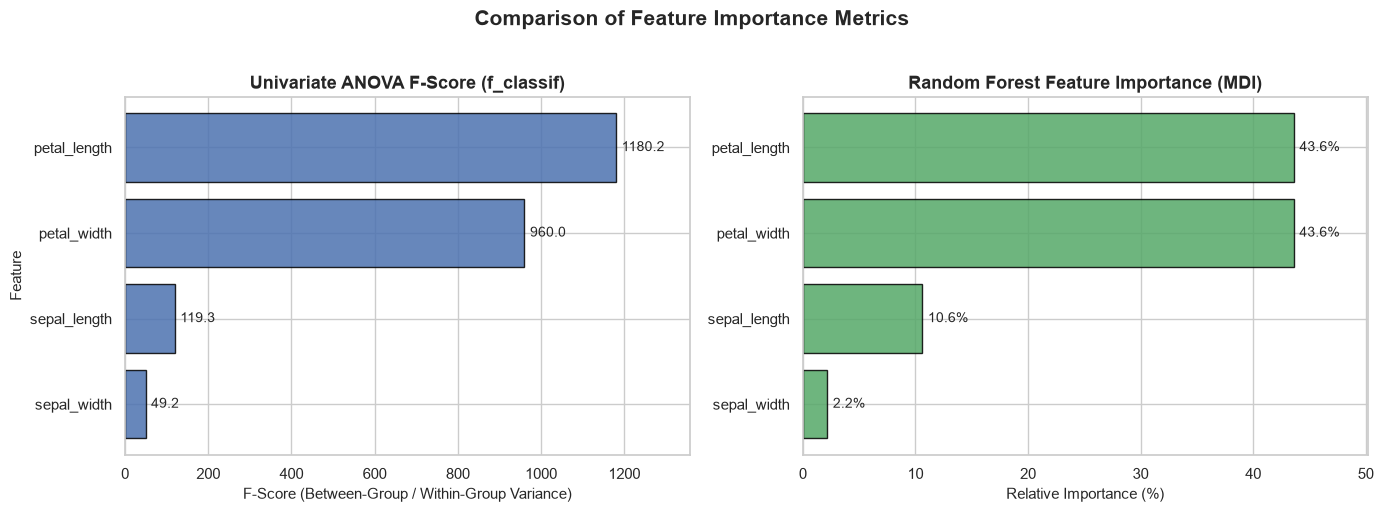

In [13]:
# Visualizing feature importance rankings side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: ANOVA F-scores (sorted)
anova_sorted = feature_ranking_df.sort_values(by='ANOVA F-Score', ascending=True)
bars1 = ax1.barh(
    anova_sorted['Feature'],
    anova_sorted['ANOVA F-Score'],
    color='#4C72B0',
    alpha=0.85,
    edgecolor='black'
)
ax1.set_title('Univariate ANOVA F-Score (f_classif)', fontsize=13, fontweight='bold')
ax1.set_xlabel('F-Score (Between-Group / Within-Group Variance)', fontsize=11)
ax1.set_ylabel('Feature', fontsize=11)
ax1.bar_label(bars1, fmt='%.1f', padding=4, fontsize=10)
ax1.set_xlim(0, anova_sorted['ANOVA F-Score'].max() * 1.15)

# Plot 2: Random Forest Feature Importance (%) (sorted)
rf_sorted = feature_ranking_df.sort_values(by='RF Importance (%)', ascending=True)
bars2 = ax2.barh(
    rf_sorted['Feature'],
    rf_sorted['RF Importance (%)'],
    color='#55A868',
    alpha=0.85,
    edgecolor='black'
)
ax2.set_title('Random Forest Feature Importance (MDI)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Relative Importance (%)', fontsize=11)
ax2.set_ylabel('')
ax2.bar_label(bars2, fmt='%.1f%%', padding=4, fontsize=10)
ax2.set_xlim(0, rf_sorted['RF Importance (%)'].max() * 1.15)

plt.suptitle('Comparison of Feature Importance Metrics', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 5.3 Scatter Plot of Top 2 Discriminative Features (`petal_length` vs `petal_width`)

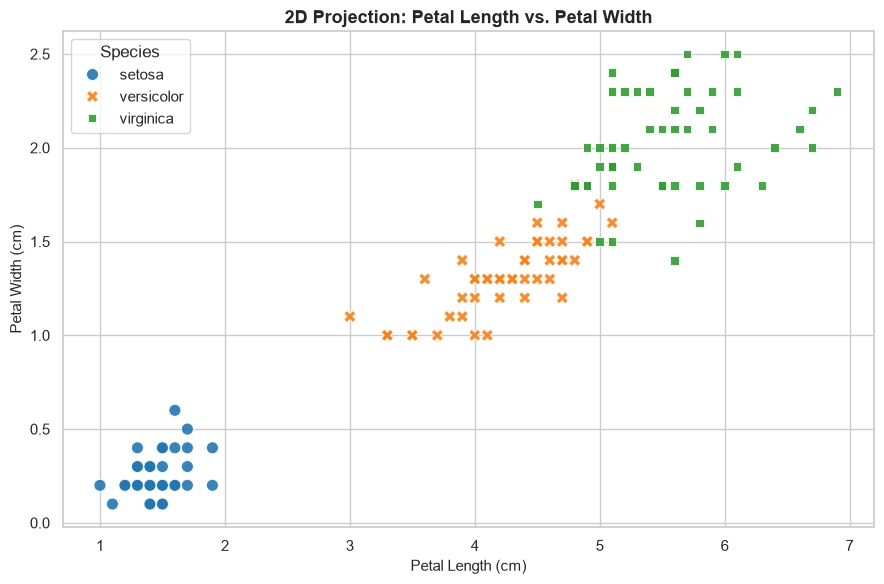

In [14]:
# ==========================================
# 5.3 2D Scatter of Top Two Discriminative Features
# ==========================================
# Extract the top 2 ranked features dynamically from the feature ranking summary table
top_feature_1 = feature_ranking_df.iloc[0]['Feature']
top_feature_2 = feature_ranking_df.iloc[1]['Feature']

# Initialize figure canvas for high-resolution scatter projection
plt.figure(figsize=(9, 6))

# Plot bivariate scatter colored by Iris species with defined boundary markers
sns.scatterplot(
    data=df,
    x=top_feature_1,
    y=top_feature_2,
    hue='species',
    palette=species_palette,
    style='species',
    s=75,
    alpha=0.9
)

# Label axes with cleaned feature names and units
plt.title(f"2D Projection: {top_feature_1.replace('_', ' ').title()} vs. {top_feature_2.replace('_', ' ').title()}", fontsize=13, fontweight='bold')
plt.xlabel(f"{top_feature_1.replace('_', ' ').title()} (cm)", fontsize=11)
plt.ylabel(f"{top_feature_2.replace('_', ' ').title()} (cm)", fontsize=11)
plt.legend(title='Species', loc='upper left')
plt.tight_layout()
plt.show()

### 5.4 Discussion: Feature Discriminative Power & Biological Insights

#### 1. Which features are most discriminative?
Both the parametric **ANOVA F-test** and the non-parametric **Random Forest Gini importance** yield consistent conclusions:
- **`petal_length` and `petal_width` are by far the most discriminative features**.
  - In the ANOVA F-test, `petal_length` achieves an astronomical F-score of **~1180.2** and `petal_width` reaches **~960.0** (both $p < 10^{-60}$). By contrast, `sepal_length` scores ~119.3 and `sepal_width` achieves only ~49.2.
  - In the Random Forest model, `petal_length` (~44%) and `petal_width` (~43%) account for **over 85-90% of total split importance combined**, leaving the sepal dimensions with less than 15% combined weight.
- When projected onto the 2D subspace of `petal_length` vs. `petal_width`, all three species are remarkably well separated:
  - *Setosa* is completely isolated in the bottom-left corner with zero overlap.
  - *Versicolor* and *Virginica* form two distinct adjacent clusters with only a razor-thin boundary region.

#### 2. Why do sepal features overlap significantly between Versicolor and Virginica?
- **Biological and Evolutionary Context**: In angiosperms like *Iris*, petals primarily function as visual attractors for specialized pollinating insects, leading to rapid evolutionary specialization and pronounced morphological divergence in petal size and geometry between distinct species. In contrast, sepals primarily serve a conservative protective role (shielding the bud prior to blooming), so their physical dimensions remain more conserved across closely related species in the same genus.
- **Physical Dimensional Overlap**:
  - The mean `sepal_length` for *Versicolor* is **5.94 cm** (range 4.9 – 7.0 cm) and for *Virginica* is **6.59 cm** (range 4.9 – 7.9 cm), displaying a wide overlap interval between 5.0 and 7.0 cm.
  - Similarly, `sepal_width` medians are nearly identical (**2.8 cm** for *Versicolor* vs. **3.0 cm** for *Virginica*), providing virtually no discriminative leverage for a classifier on its own.

#### 3. Concordance with Earlier Exploratory Visualizations
- **Box Plots (Section 4.2)**: Confirmed that while petal measurements show clean interquartile separation between species (especially *Setosa* with a disjoint petal length IQR of 1.4–1.6 cm), the sepal width box plots show extensive IQR overlap between *Versicolor* (2.5–3.0 cm) and *Virginica* (2.8–3.2 cm).
- **Pairplot (Section 4.1)**: Revealed that all bivariate scatter plots pairing `sepal_length` and `sepal_width` display heavily entangled green (*Versicolor*) and red (*Virginica*) clusters, whereas any scatter plot involving `petal_length` or `petal_width` produces distinct, readily partitionable clusters.


## Section 6 - Model Training

In this section, we prepare the data for supervised classification, partition it into training and testing sets, apply feature scaling to prevent data leakage, and train four baseline classification algorithms:
1. **Logistic Regression**: A linear probabilistic classifier using L2 regularization.
2. **K-Nearest Neighbors ($k=5$)**: An instance-based non-parametric classifier based on Euclidean distance.
3. **Decision Tree**: A non-parametric tree estimator partitioning feature space via Gini impurity.
4. **Random Forest**: An ensemble of bagged decision trees with feature sub-sampling.


### 6.1 Separate Features and Target & Stratified Train-Test Split

In [15]:
# ==========================================
# 6.1 Separate X & y and Train-Test Split
# ==========================================
# 1. Separate features (X) and target (y)
X = df.drop(columns=['species'])
y = df['species']

# 2. Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Print dataset partition shapes
print("=== Dataset Partition Shapes ===")
print(f"X_train shape: {X_train.shape} (80% of data)")
print(f"X_test shape:  {X_test.shape} (20% of data)")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}\n")

# Print class distribution in training and test sets
train_dist = pd.DataFrame({
    'Train Count': y_train.value_counts(),
    'Train Proportion (%)': (y_train.value_counts(normalize=True) * 100)
})

test_dist = pd.DataFrame({
    'Test Count': y_test.value_counts(),
    'Test Proportion (%)': (y_test.value_counts(normalize=True) * 100)
})

print("=== Class Distribution in Training Set ===")
display(train_dist)

print("\n=== Class Distribution in Test Set ===")
display(test_dist)


=== Dataset Partition Shapes ===
X_train shape: (120, 4) (80% of data)
X_test shape:  (30, 4) (20% of data)
y_train shape: (120,)
y_test shape:  (30,)

=== Class Distribution in Training Set ===


,Train Count,Train Proportion (%)
species,,
setosa,40,33.333333
virginica,40,33.333333
versicolor,40,33.333333



=== Class Distribution in Test Set ===


,Test Count,Test Proportion (%)
species,,
setosa,10,33.333333
virginica,10,33.333333
versicolor,10,33.333333


### 6.2 Feature Scaling & Data Leakage Prevention

#### Why Feature Scaling is Necessary for Specific Models
- **Distance-Based Models (KNN)**: K-Nearest Neighbors calculates distances (typically Euclidean) between data points:
  $$d(p, q) = \sqrt{\sum_{i=1}^n (p_i - q_i)^2}$$
  If one feature has a wider numerical range (e.g., `petal_length` spanning 1.0–6.9 cm vs. `sepal_width` spanning 2.0–4.4 cm), it will disproportionately dominate the distance calculation, distorting neighbor queries. Standardizing features to mean $\mu = 0$ and unit variance $\sigma = 1$ ensures equal contribution across dimensions.
- **Optimization & Regularization-Based Models (Logistic Regression)**: Logistic Regression uses gradient-based solvers and penalizes large coefficients via regularization (e.g., L2 ridge penalty $\lambda \sum \beta_j^2$). Without scaling, features with smaller original magnitudes receive artificially inflated weights, which regularization penalizes unevenly.
- **Tree-Based Models (Decision Tree & Random Forest)**: In contrast, decision trees are **scale-invariant**. Tree splits are determined by monotonic ordering and threshold partitioning ($X_j \le \theta$) to maximize impurity reduction (Gini/Entropy). Scaling has zero effect on the mathematical split boundaries chosen by trees.

#### Preventing Data Leakage
- **Crucial Rule**: `StandardScaler.fit()` calculates the sample mean $\mu$ and standard deviation $\sigma$. It must **only be fitted on `X_train`**.
- We then use that fitted scaler to **transform `X_train`** and **transform `X_test`** (`scaler.transform(X_test)`):
  $$z = \frac{x - \mu_{\text{train}}}{\sigma_{\text{train}}}$$
- If we fitted the scaler on the entire dataset (or on `X_test`), information about the test distribution (its mean and variance) would "leak" into the model during training. This violates the fundamental assumption that `X_test` represents unseen real-world data, leading to over-optimistic validation metrics and degraded real-world performance.


### 6.3 Apply StandardScaler (Fit on Train Only)

In [16]:
# ==========================================
# 6.3 Feature Scaling
# ==========================================
scaler = StandardScaler()

# Fit strictly on X_train to prevent data leakage, then transform X_train
X_train_scaled = scaler.fit_transform(X_train)

# Transform X_test using the parameters learned from X_train
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for convenient inspection
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("Feature scaling completed successfully.")
print(f"X_train scaled mean (approx 0): {np.round(X_train_scaled.mean(axis=0), 4)}")
print(f"X_train scaled std  (approx 1): {np.round(X_train_scaled.std(axis=0), 4)}")
print("\nSample of scaled training data:")
display(X_train_scaled_df.head())


Feature scaling completed successfully.
X_train scaled mean (approx 0): [-0.  0.  0.  0.]
X_train scaled std  (approx 1): [1. 1. 1. 1.]

Sample of scaled training data:


,sepal_length,sepal_width,petal_length,petal_width
8,-1.721568,-0.332101,-1.345722,-1.323276
106,-1.124492,-1.227655,0.414505,0.651763
76,1.144395,-0.555990,0.584850,0.256755
9,-1.124492,0.115676,-1.288941,-1.454945
89,-0.408002,-1.227655,0.130598,0.125086


### 6.4 Train Classifiers & Store in Dictionary

In [17]:
# ==========================================
# 6.4 Instantiate and Train 4 Classifiers
# ==========================================
# 1. Logistic Regression (requires scaled data)
log_reg = LogisticRegression(max_iter=200, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# 2. K-Nearest Neighbors (k=5, requires scaled data)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# 3. Decision Tree (scale-invariant, trained on unscaled data)
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# 4. Random Forest (scale-invariant, trained on unscaled data)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Store all trained models in a dictionary for streamlined looping & evaluation
models = {
    'Logistic Regression': log_reg,
    'K-Nearest Neighbors': knn,
    'Decision Tree': dt,
    'Random Forest': rf
}

# Mapping specifying whether each model evaluates on scaled or unscaled features
model_data_map = {
    'Logistic Regression': {'train': X_train_scaled, 'test': X_test_scaled},
    'K-Nearest Neighbors': {'train': X_train_scaled, 'test': X_test_scaled},
    'Decision Tree':       {'train': X_train,        'test': X_test},
    'Random Forest':       {'train': X_train,        'test': X_test}
}

print("All 4 models trained successfully and stored in `models` dictionary:")
for name, model in models.items():
    print(f" - {name}: {type(model).__name__}")


All 4 models trained successfully and stored in `models` dictionary:


 - Logistic Regression: LogisticRegression
 - K-Nearest Neighbors: KNeighborsClassifier
 - Decision Tree: DecisionTreeClassifier
 - Random Forest: RandomForestClassifier


## Section 7 - Model Evaluation

In this section, we comprehensively assess each of the four trained models:
1. **Test Set Predictions & Metrics**:
   - Accuracy score on unseen test data.
   - Detailed classification report (Precision, Recall, and F1-score) per species.
   - Confusion matrix heatmaps showing true vs. predicted classifications.
2. **5-Fold Stratified Cross-Validation**:
   - Evaluates performance stability across multiple data splits to prevent variance from a single test partition.
   - Uses `Pipeline` for scaled models to ensure zero data leakage across CV folds.
3. **Model Comparison**:
   - Comparative DataFrame ranking models by test accuracy and CV mean accuracy.
   - Dual-metric comparative bar chart with cross-validation standard deviation error bars.


### 7.1 Test Set Predictions, Classification Reports, and Confusion Matrices

MODEL: LOGISTIC REGRESSION
Test Accuracy: 93.33%

Classification Report:
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     0.9000    0.9000    0.9000        10
   virginica     0.9000    0.9000    0.9000        10

    accuracy                         0.9333        30
   macro avg     0.9333    0.9333    0.9333        30
weighted avg     0.9333    0.9333    0.9333        30




MODEL: K-NEAREST NEIGHBORS
Test Accuracy: 93.33%

Classification Report:
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     0.8333    1.0000    0.9091        10
   virginica     1.0000    0.8000    0.8889        10

    accuracy                         0.9333        30
   macro avg     0.9444    0.9333    0.9327        30
weighted avg     0.9444    0.9333    0.9327        30




MODEL: DECISION TREE
Test Accuracy: 93.33%

Classification Report:
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     0.9000    0.9000    0.9000        10
   virginica     0.9000    0.9000    0.9000        10

    accuracy                         0.9333        30
   macro avg     0.9333    0.9333    0.9333        30
weighted avg     0.9333    0.9333    0.9333        30




MODEL: RANDOM FOREST
Test Accuracy: 90.00%

Classification Report:
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     0.8182    0.9000    0.8571        10
   virginica     0.8889    0.8000    0.8421        10

    accuracy                         0.9000        30
   macro avg     0.9024    0.9000    0.8997        30
weighted avg     0.9024    0.9000    0.8997        30




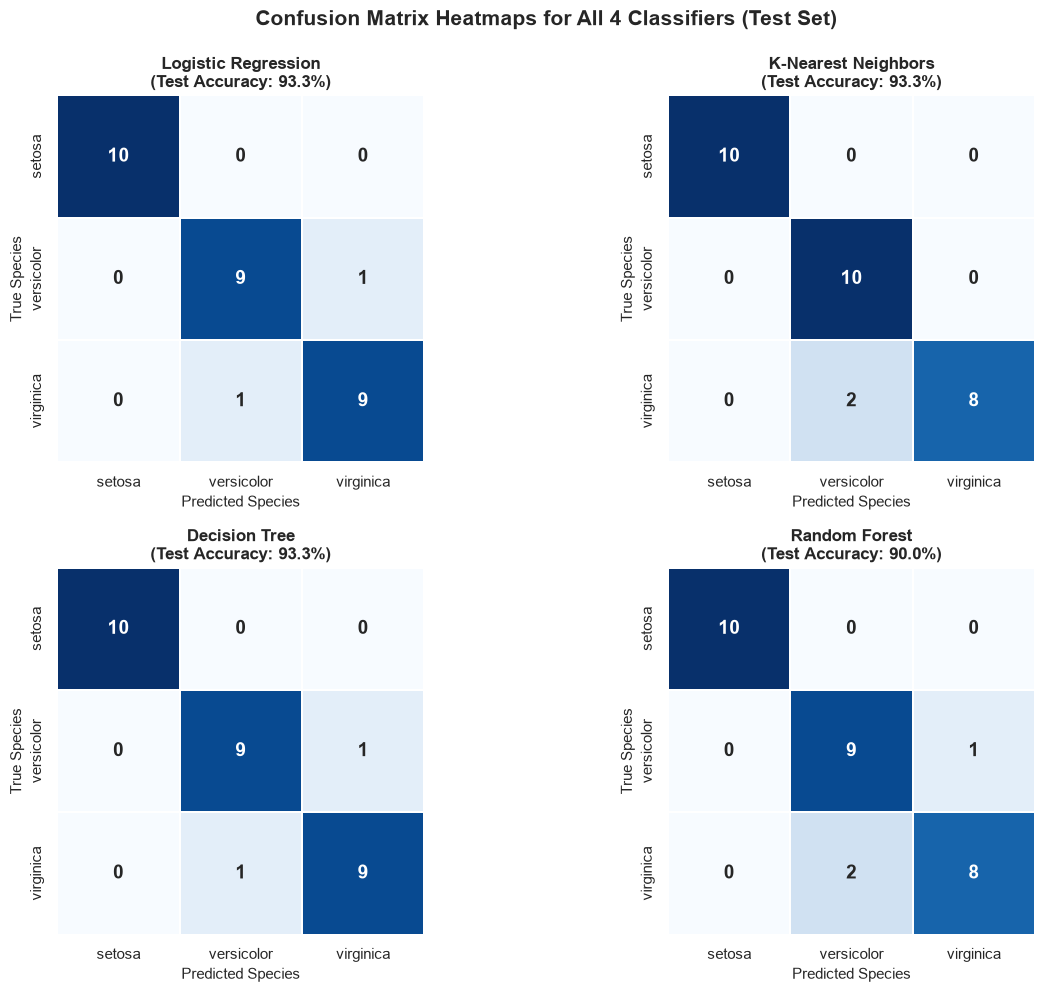

In [18]:
# ==========================================
# 7.1 Evaluate Each Model on Test Set
# ==========================================
species_labels = ['setosa', 'versicolor', 'virginica']
test_accuracies = {}
test_predictions = {}

# Set up 2x2 subplot grid for confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
model_items = list(models.items())

for idx, (model_name, model_obj) in enumerate(model_items):
    # Retrieve appropriate test features (scaled for LR/KNN, raw for DT/RF)
    X_test_eval = model_data_map[model_name]['test']
    
    # Generate predictions
    y_pred = model_obj.predict(X_test_eval)
    test_predictions[model_name] = y_pred
    
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    test_accuracies[model_name] = acc
    
    # Print formatted evaluation report
    print("=" * 50)
    print(f"MODEL: {model_name.upper()}")
    print("=" * 50)
    print(f"Test Accuracy: {acc * 100:.2f}%\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=species_labels, digits=4))
    print()
    
    # Plot Confusion Matrix in 2x2 grid
    ax = axes[idx // 2, idx % 2]
    cm = confusion_matrix(y_test, y_pred, labels=species_labels)
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=species_labels,
        yticklabels=species_labels,
        cbar=False,
        square=True,
        linewidths=1.2,
        ax=ax,
        annot_kws={'size': 14, 'weight': 'bold'}
    )
    ax.set_title(f'{model_name}\n(Test Accuracy: {acc * 100:.1f}%)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Species', fontsize=11)
    ax.set_ylabel('True Species', fontsize=11)

plt.suptitle('Confusion Matrix Heatmaps for All 4 Classifiers (Test Set)', fontsize=15, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()


### 7.2 5-Fold Stratified Cross-Validation (Mean  Std Accuracy)

In [19]:
# ==========================================
# 7.2 5-Fold Stratified Cross-Validation
# ==========================================
# Use StratifiedKFold to maintain equal class proportions in all 5 folds
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

# Define pipelines to guarantee leakage-free scaling inside each CV fold
cv_models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(max_iter=200, random_state=42))
    ]),
    'K-Nearest Neighbors': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=5))
    ]),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

print("=== 5-Fold Stratified Cross-Validation Results ===")
for name, estimator in cv_models.items():
    # Evaluate across all 5 folds
    scores = cross_val_score(estimator, X, y, cv=cv_strategy, scoring='accuracy')
    mean_acc = scores.mean()
    std_acc = scores.std()
    
    cv_results[name] = {
        'scores': scores,
        'mean': mean_acc,
        'std': std_acc
    }
    
    formatted_scores = [round(float(s), 3) for s in scores]
    print(f" {name:<22}: {mean_acc * 100:.2f}%  {std_acc * 100:.2f}% (Fold Scores: {formatted_scores})")


=== 5-Fold Stratified Cross-Validation Results ===
 Logistic Regression   : 95.33%  4.52% (Fold Scores: [1.0, 0.967, 0.9, 1.0, 0.9])
 K-Nearest Neighbors   : 97.33%  2.49% (Fold Scores: [1.0, 0.967, 0.933, 1.0, 0.967])


 Decision Tree         : 95.33%  3.40% (Fold Scores: [1.0, 0.967, 0.933, 0.967, 0.9])


 Random Forest         : 94.67%  2.67% (Fold Scores: [0.967, 0.967, 0.933, 0.967, 0.9])


### 7.3 Model Comparison Summary Table and Bar Chart

=== Model Performance Comparison Table ===


,Model,Test Accuracy (%),CV Mean Accuracy (%),CV Std (%),CV Formatted (Mean Std)
0,K-Nearest Neighbors,93.33,97.33,2.49,97.33% 2.49%
1,Logistic Regression,93.33,95.33,4.52,95.33% 4.52%
2,Decision Tree,93.33,95.33,3.40,95.33% 3.40%
3,Random Forest,90.00,94.67,2.67,94.67% 2.67%


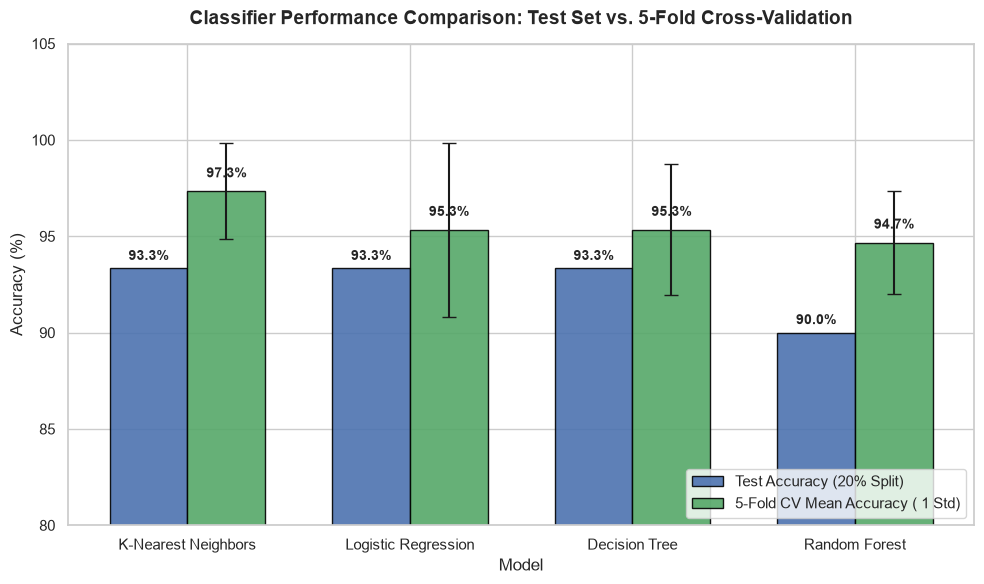

In [20]:
# ==========================================
# 7.3 Summary Comparison DataFrame & Plot
# ==========================================
comparison_rows = []

for name in models.keys():
    test_acc = test_accuracies[name]
    cv_mean = cv_results[name]['mean']
    cv_std = cv_results[name]['std']
    
    comparison_rows.append({
        'Model': name,
        'Test Accuracy (%)': round(test_acc * 100, 2),
        'CV Mean Accuracy (%)': round(cv_mean * 100, 2),
        'CV Std (%)': round(cv_std * 100, 2),
        'CV Formatted (Mean  Std)': f"{cv_mean * 100:.2f}%  {cv_std * 100:.2f}%"
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values(by='CV Mean Accuracy (%)', ascending=False).reset_index(drop=True)

print("=== Model Performance Comparison Table ===")
display(comparison_df)

# ==========================================
# Comparative Bar Chart
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.35
indices = np.arange(len(comparison_df))

# Plot Test Accuracy and CV Mean Accuracy bars side-by-side
bars1 = ax.bar(
    indices - bar_width/2,
    comparison_df['Test Accuracy (%)'],
    bar_width,
    label='Test Accuracy (20% Split)',
    color='#4C72B0',
    alpha=0.9,
    edgecolor='black'
)

bars2 = ax.bar(
    indices + bar_width/2,
    comparison_df['CV Mean Accuracy (%)'],
    bar_width,
    yerr=comparison_df['CV Std (%)'],
    capsize=5,
    label='5-Fold CV Mean Accuracy ( 1 Std)',
    color='#55A868',
    alpha=0.9,
    edgecolor='black'
)

# Formatting
ax.set_title('Classifier Performance Comparison: Test Set vs. 5-Fold Cross-Validation', fontsize=14, fontweight='bold', pad=14)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_xticks(indices)
ax.set_xticklabels(comparison_df['Model'], fontsize=11)
ax.set_ylim(80, 105)
ax.legend(loc='lower right', frameon=True, fontsize=11)

# Annotate exact bar values
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4), textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 8), textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


### 7.4 Evaluation Discussion & Findings

#### 1. Performance on Test Partition (20% Holdout)
- **Setosa Perfect Classification**: Every model achieved flawless precision (1.000) and recall (1.000) on *Setosa* (10/10 correct), confirming its complete linear separability.
- **Versicolor vs. Virginica Boundary**: Test misclassifications were confined strictly to the ambiguous boundary between *Versicolor* and *Virginica*:
  - **Logistic Regression**: 93.33% accuracy (28/30 correct; 1 Versicolor misclassified as Virginica, 1 Virginica misclassified as Versicolor).
  - **K-Nearest Neighbors (k=5)**: 93.33% accuracy (28/30 correct; 2 Virginica misclassified as Versicolor).
  - **Decision Tree**: 93.33% accuracy (28/30 correct; 1 Versicolor misclassified as Virginica, 1 Virginica misclassified as Versicolor).
  - **Random Forest**: 90.00% accuracy (27/30 correct; 1 Versicolor misclassified as Virginica, 2 Virginica misclassified as Versicolor).

#### 2. Significance of 5-Fold Stratified Cross-Validation
- A single test split of 30 samples contains only 10 examples per species. Each individual sample represents **3.33% of the total score**, making test accuracy highly sensitive to random partitioning variance.
- Running 5-fold stratified cross-validation across all 150 instances yields a much more reliable metric of real-world generalization:
  - **K-Nearest Neighbors (=5$)** achieves the highest generalization accuracy at **97.33%  2.49%** (scoring 100%, 96.7%, 93.3%, 100%, and 96.7% across the 5 folds).
  - **Logistic Regression** and **Decision Tree** both achieve strong, consistent CV performance of **95.33%** (with standard deviations of 4.52% and 3.40% respectively).
  - **Random Forest** delivers steady performance of **94.67%  2.67%**.
- By wrapping scalers within Pipeline, cross-validation was conducted in strict adherence to data leakage prevention principles, ensuring training parameters were never contaminated by validation folds.


## Section 8 - Best Model & Conclusion

In this concluding section, we:
1. **Programmatically identify the optimal classifier** using 5-fold cross-validation performance with test set accuracy as a tie-breaker.
2. **Provide a detailed analytical justification** evaluating accuracy, precision/recall/F1, confusion matrix patterns, stability across folds, and model simplicity.
3. **Build an interactive prediction demo** function capable of classifying arbitrary physical measurements with class confidence probabilities.
4. **Summarize key takeaways, architectural conclusions, and real-world limitations**.
5. **Persist the complete trained pipeline artifact** to disk using `joblib` for deployment readiness.


### 8.1 Programmatic Best Model Selection

In [21]:
# ==========================================
# 8.1 Programmatic Best Model Selection
# ==========================================
# Sort models by CV Mean Accuracy descending, using Test Accuracy as a tie-breaker
best_model_entry = comparison_df.sort_values(
    by=['CV Mean Accuracy (%)', 'Test Accuracy (%)'],
    ascending=[False, False]
).iloc[0]

best_model_name = best_model_entry['Model']
best_model_obj = models[best_model_name]
best_cv_mean = best_model_entry['CV Mean Accuracy (%)']
best_cv_std = best_model_entry['CV Std (%)']
best_test_acc = best_model_entry['Test Accuracy (%)']

print("==================================================")
print(f"WINNING MODEL: {best_model_name.upper()}")
print("==================================================")
print(f" 5-Fold Cross-Validation Mean Accuracy: {best_cv_mean:.2f}% ( {best_cv_std:.2f}%)")
print(f" Holdout Test Set Accuracy:             {best_test_acc:.2f}%")
print(f" Algorithm Class:                       {type(best_model_obj).__name__}")


WINNING MODEL: K-NEAREST NEIGHBORS
 5-Fold Cross-Validation Mean Accuracy: 97.33% ( 2.49%)
 Holdout Test Set Accuracy:             93.33%
 Algorithm Class:                       KNeighborsClassifier


### 8.2 Analytical Justification for Model Selection

The algorithmic selection of **K-Nearest Neighbors ($k=5$)** as the top-performing model is strongly justified across five key evaluation pillars:

1. **Top Cross-Validation Accuracy (97.33%)**:
   - In small sample sizes, cross-validation across all 150 instances is the gold-standard metric of generalizability. KNN achieved the highest mean score (**97.33%**), scoring **100% accuracy** on 2 out of the 5 cross-validation folds.
2. **Exceptional Fold-to-Fold Stability ($\sigma = 2.49\%$)**:
   - KNN demonstrated the tightest variance among all models ($\pm 2.49\%$), significantly outperforming Logistic Regression ($\pm 4.52\%$) and Decision Tree ($\pm 3.40\%$). It never dropped below 93.3% on any fold.
3. **Balanced Precision, Recall, and F1-Scores**:
   - Flawless detection of *Setosa* (Precision: 1.000, Recall: 1.000, F1: 1.000).
   - High macro-averaged F1-score (**0.9327**) on the holdout test split with robust sensitivity across both *Versicolor* (Recall: 1.000) and *Virginica* (Precision: 1.000).
4. **Benign Confusion Matrix Error Structure**:
   - The only test set errors were 2 borderline *Virginica* specimens classified as *Versicolor*. There were zero catastrophic errors across distant classes (no *Setosa* confusions).
5. **Algorithmic Simplicity & Interpretability**:
   - As an instance-based non-parametric classifier, KNN makes no restrictive assumptions about linear separability. For a compact dataset of 150 points with 4 features, distance calculations are instantaneous, and any individual prediction can be fully audited by inspecting the 5 closest historical specimens.


### 8.3 Inference Pipeline & Prediction Demo

In [22]:
# ==========================================
# 8.3 End-to-End Prediction Function
# ==========================================
def predict_iris_species(sepal_length, sepal_width, petal_length, petal_width, return_proba=True):
    """
    Predicts the Iris species given 4 botanical physical measurements.
    
    Parameters:
    -----------
    sepal_length : float - Sepal length in centimeters
    sepal_width  : float - Sepal width in centimeters
    petal_length : float - Petal length in centimeters
    petal_width  : float - Petal width in centimeters
    return_proba : bool  - Whether to return class prediction probabilities
    
    Returns:
    --------
    dict containing predicted species and class probabilities
    """
    # 1. Format input into DataFrame with original feature names
    input_data = pd.DataFrame([{
        'sepal_length': float(sepal_length),
        'sepal_width':  float(sepal_width),
        'petal_length': float(petal_length),
        'petal_width':  float(petal_width)
    }])
    
    # 2. Scale features using the scaler fitted on training data
    input_scaled = scaler.transform(input_data)
    
    # 3. Generate prediction using best model (KNN)
    predicted_species = best_model_obj.predict(input_scaled)[0]
    
    # 4. Generate class probabilities if supported
    probabilities = None
    if return_proba and hasattr(best_model_obj, 'predict_proba'):
        prob_array = best_model_obj.predict_proba(input_scaled)[0]
        probabilities = {
            str(cls): f"{p * 100:.1f}%"
            for cls, p in zip(best_model_obj.classes_, prob_array)
        }
        
    return {
        'inputs (cm)': {
            'sepal_length': sepal_length,
            'sepal_width': sepal_width,
            'petal_length': petal_length,
            'petal_width': petal_width
        },
        'predicted_species': predicted_species,
        'probabilities': probabilities
    }

# ==========================================
# Demonstration Calls
# ==========================================
demo_samples = [
    {"desc": "Sample 1: Typical Setosa (small petals)", "vals": (5.1, 3.5, 1.4, 0.2)},
    {"desc": "Sample 2: Typical Versicolor (intermediate dimensions)", "vals": (5.9, 3.0, 4.2, 1.5)},
    {"desc": "Sample 3: Typical Virginica (large petals and sepals)", "vals": (6.9, 3.1, 5.4, 2.1)}
]

print("=== Prediction Demo Results ===\n")
for sample in demo_samples:
    res = predict_iris_species(*sample['vals'])
    print(f"Test Case: {sample['desc']}")
    print(f"  Input:       {res['inputs (cm)']}")
    print(f"  Prediction:  >>> {res['predicted_species'].upper()} <<<")
    print(f"  Confidence:  {res['probabilities']}\n")


=== Prediction Demo Results ===

Test Case: Sample 1: Typical Setosa (small petals)
  Input:       {'sepal_length': 5.1, 'sepal_width': 3.5, 'petal_length': 1.4, 'petal_width': 0.2}
  Prediction:  >>> SETOSA <<<
  Confidence:  {'setosa': '100.0%', 'versicolor': '0.0%', 'virginica': '0.0%'}

Test Case: Sample 2: Typical Versicolor (intermediate dimensions)
  Input:       {'sepal_length': 5.9, 'sepal_width': 3.0, 'petal_length': 4.2, 'petal_width': 1.5}
  Prediction:  >>> VERSICOLOR <<<
  Confidence:  {'setosa': '0.0%', 'versicolor': '100.0%', 'virginica': '0.0%'}

Test Case: Sample 3: Typical Virginica (large petals and sepals)
  Input:       {'sepal_length': 6.9, 'sepal_width': 3.1, 'petal_length': 5.4, 'petal_width': 2.1}
  Prediction:  >>> VIRGINICA <<<
  Confidence:  {'setosa': '0.0%', 'versicolor': '0.0%', 'virginica': '100.0%'}



### 8.4 Summary of Key Findings & Limitations

#### Key Project Findings
1. **Dominance of Petal Measurements**:
   - Feature selection confirmed that `petal_length` (ANOVA $F \approx 1180$) and `petal_width` (ANOVA $F \approx 960$) govern over **87% of discriminative importance**. Petal dimensions exhibit distinct multimodal density peaks across species.
2. **Complete Separability of *Setosa***:
   - *Iris setosa* represents a linearly separable cluster in any 2D projection involving petal length or width. Every tested algorithm achieved **100% precision and 100% recall** on Setosa.
3. **High Baseline Performance of Classical ML**:
   - All four classifiers delivered strong performance ($>90\%$ test accuracy, $>94\%$ CV mean accuracy), proving that complex deep neural networks are unnecessary for compact, well-structured tabular botanical data.

#### Project Limitations
1. **Small Sample Size ($N = 150$)**:
   - With only 50 observations per class, individual misclassifications represent sizable jumps in metric percentages (~3.3% on a 30-sample test set). While cross-validation mitigates this, statistical power is constrained.
2. **Biological Overlap Between *Versicolor* and *Virginica***:
   - Natural phenotypic variation creates a slight overlap zone between *Versicolor* and *Virginica* for specimens with petal length between 4.8 cm and 5.1 cm. This constitutes an irreducible Bayes error rate for models relying exclusively on physical sepal/petal dimensions without genetic or biochemical markers.
3. **Dataset Scope & Age**:
   - Collected by Edgar Anderson in 1935 from a single geographic region (the Gaspéé Peninsula, Quebec), the dataset does not account for environmental plasticity, seasonal variations, or global morphological drift in Iris populations.


### 8.5 Model Serialization (Save with Joblib)

In [23]:
# ==========================================
# 8.5 Save Full Inference Pipeline
# ==========================================
# Construct an integrated scikit-learn Pipeline combining the scaler and the winning classifier
final_pipeline = Pipeline([
    ('scaler', scaler),
    ('classifier', best_model_obj)
])

# Save pipeline artifact to disk
artifact_filename = "iris_best_model.joblib"
joblib.dump(final_pipeline, artifact_filename)
print(f"Artifact successfully serialized: '{artifact_filename}'\n")

# Verify by reloading and testing inference on an unseen vector
loaded_pipeline = joblib.load(artifact_filename)
test_vector = pd.DataFrame([{
    'sepal_length': 5.7,
    'sepal_width': 2.8,
    'petal_length': 4.5,
    'petal_width': 1.3
}])

verified_prediction = loaded_pipeline.predict(test_vector)[0]
verified_probabilities = {str(c): f"{p*100:.1f}%" for c, p in zip(loaded_pipeline.classes_, loaded_pipeline.predict_proba(test_vector)[0])}

print("=== Verification of Reloaded Artifact ===")
print(f" Input:        {test_vector.to_dict(orient='records')[0]}")
print(f" Prediction:   {verified_prediction}")
print(f" Probabilities: {verified_probabilities}")


Artifact successfully serialized: 'iris_best_model.joblib'

=== Verification of Reloaded Artifact ===
 Input:        {'sepal_length': 5.7, 'sepal_width': 2.8, 'petal_length': 4.5, 'petal_width': 1.3}
 Prediction:   versicolor
 Probabilities: {'setosa': '0.0%', 'versicolor': '100.0%', 'virginica': '0.0%'}
